# PLS Correlation analysis of polygenic risk scores
Maria B. Jelen

In [19]:
# Import packages
import pandas as pd
import os
import numpy as np
import pyls
from matplotlib.colors import ListedColormap
import matplotlib as plt

In [20]:
# Set plotting parameters
plt.rcParams.update({
    "font.family": "Arial",
    "font.weight": "normal"
})

### PLS Correlation of polygenic risk scores and psychopathology profile membership 

In [21]:
pgr_mock = pd.read_csv('pgr_mock.csv')
print(pgr_mock.shape)

(200, 18)


In [22]:
# Load psychopathology profile membership dataframe
membership_df = pd.read_csv('som_island_membership.csv')
print(membership_df.shape)

(200, 3)


In [23]:
# Replace Infs with NaN, then delete NaN
pgr_clean = pgr_mock.replace([np.inf, -np.inf], np.nan).dropna()
membership_df_clean = membership_df.replace([np.inf, -np.inf], np.nan).dropna()

print(pgr_clean.shape)
print(membership_df_clean.shape)

(200, 18)
(200, 3)


In [24]:
# Keep participants who have PGR scores
common_ids = set(pgr_clean["Participant_ID"]).intersection(membership_df_clean["Participant_ID"])

PGS_aligned = pgr_clean[pgr_clean["Participant_ID"].isin(common_ids)].sort_values("Participant_ID").reset_index(drop=True)
membership_aligned = membership_df_clean[membership_df_clean["Participant_ID"].isin(common_ids)].sort_values("Participant_ID").reset_index(drop=True)

In [25]:
from sklearn.preprocessing import StandardScaler

# Check there are no NaN values
print(f"Number of NaN values in PGS: {PGS_aligned.isna().sum().sum()}")
print(f"Number of NaN values in profiles: {membership_aligned.isna().sum().sum()}")

# Ensure X and Y are sorted by ID to have the same row order
PGS_aligned = PGS_aligned.sort_values(by='Participant_ID').reset_index(drop=True)
membership_aligned = membership_aligned.sort_values(by='Participant_ID').reset_index(drop=True)

# Separate the IDs from the data
PGS_h = PGS_aligned.drop('Participant_ID', axis=1).values
membership_h = membership_aligned.drop('Participant_ID', axis=1).values

# Scale
PGS_scaled = StandardScaler().fit_transform(PGS_h)
membership_scaled = StandardScaler().fit_transform(membership_h)

print(f"Shape of X_scaled: {PGS_scaled.shape}")
print(f"Shape of Y_scaled: {membership_scaled.shape}")

Number of NaN values in PGS: 0
Number of NaN values in profiles: 0
Shape of X_scaled: (200, 17)
Shape of Y_scaled: (200, 2)


In [26]:
# Model of PLSCorrelation
#pls_gene_mock = pyls.behavioral_pls(
#    PGS_scaled, 
#    membership_scaled,
#    n_perm=1000,
#    n_boot=1000
#)

#import joblib
#joblib.dump(pls_gene_mock, 'pls_gene_test.joblib')

# p-values for each latent variable (from permutation testing)
#print("\nP-values for each Latent Variable:")
#print(pls_gene_mock.permres.pvals)

# Covariance explained by each latent variable
#print("\nCovariance Explained by each Latent Variable (%):")
#print(pls_gene_mock.varexp * 100)

In [27]:
# Load model
import joblib
pls_gene_mock = joblib.load('pls_gene_test.joblib')

print("\nVariance Explained (%):")
print(pls_gene_mock.varexp * 100)
print("\nP-values:")
print(pls_gene_mock.permres.pvals)


Variance Explained (%):
[77.94813268 22.05186732]

P-values:
[0.21178821 0.93206793]


C:\Users\mj03\AppData\Local\Temp\ipykernel_20596\1349121673.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(clean_labels, fontsize=8, weight='bold')
C:\Users\mj03\AppData\Local\Temp\ipykernel_20596\1349121673.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(clean_labels, fontsize=8, weight='bold')


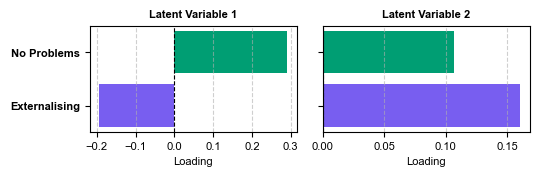

In [28]:
# Plot behavioural group (symptom profile) loadings
import matplotlib.pyplot as plt

ibm_palette = [
    '#785EF0', '#009E73'
]
label_map = {
    'externalising_1' : 'Externalising',
    'noproblems_1' : 'No Problems',
}
archetype_specific_colors = dict(zip(label_map.keys(), ibm_palette))
# set up plotting
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5.5,2.2), sharey=True)

# labels from the original Y df, dropping first column
behavioral_labels = membership_aligned.columns[1:]

# Loop through LV1 and LV2
for i in range(2):
    ax = axes[i]
    
    saliences = pls_gene_mock.y_loadings[:, i]
    
    # colors for bars
    bar_colors = [archetype_specific_colors.get(name, 'black') for name in behavioral_labels]
    
    # horizontal bar chart
    ax.barh(behavioral_labels, saliences, color=bar_colors)
    
    # overwrite labels with cleaned labels
    clean_labels = [label_map.get(name, name) for name in behavioral_labels]
    ax.set_yticklabels(clean_labels, fontsize=8, weight='bold')

    ax.set_title(f"Latent Variable {i+1}", fontsize=8, weight = 'bold')
    ax.set_xlabel("Loading", fontsize=8)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', labelsize=8)

# Restore the y-axis label on the first plot
axes[0].set_ylabel("", fontsize=14)

fig.suptitle("", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# fig.savefig("Behavior_genPLS.png", dpi=600, bbox_inches='tight')

C:\Users\mj03\AppData\Local\Temp\ipykernel_20596\1469636054.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(pretty_labels, fontsize=8, weight = 'bold')
C:\Users\mj03\AppData\Local\Temp\ipykernel_20596\1469636054.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(pretty_labels, fontsize=8, weight = 'bold')


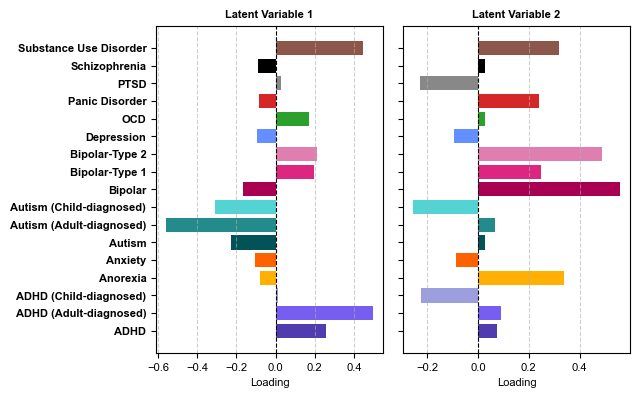

In [29]:
# Plot gene loadings
gene_palette = [
    "#503BAF", '#785EF0', '#9c9ede', # ADHD colors
    "#FFB000", "#FE6100", # Anorexia, anxiety
    "#025358","#238B8B", "#53D3D3", # Autism colors
    "#AA0052", "#DC267F", "#e07eb0", # Bipolar colors
    "#648FFF", # Depression 
    "#2ca02c", # OCD
    "#d62728", # Panic Disorder
    "#888888", # Personality Disorder
    "#000000", # PTSD
    "#8c564b"# Schizophrenia, SUD

]

label_map = {
    'adhd2022': 'ADHD', 
    'adhd_adult_2022': 'ADHD (Adult-diagnosed)', 
    'adhd_child_2022': 'ADHD (Child-diagnosed)',
    'an2019': 'Anorexia', 
    'anx2024': 'Anxiety', 
    'asd2022': 'Autism',
    'asd_late_2022': 'Autism (Adult-diagnosed)',  
    'asd_early_2022': 'Autism (Child-diagnosed)',
    'bip2024': 'Bipolar', 
    'bip_type1_2021': 'Bipolar-Type 1', 
    'bip_type2_2021': 'Bipolar-Type 2',
    'mdd2025': 'Depression', 
    'ocd2024': 'OCD', 
    'panic2019': 'Panic Disorder', 
    'ptsd2024': 'PTSD', 
    'scz2022': 'Schizophrenia',
    'sud2023': 'Substance Use Disorder'
}

archetype_specific_colors = dict(zip(label_map.keys(), gene_palette))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6.5, 4.6), sharey=True)

behavioral_labels = list(label_map.keys())
X_numeric = np.array(PGS_h, dtype=float)

# Calculate loadings
x_loadings = np.zeros_like(pls_gene_mock.x_weights)
for lv in range(pls_gene_mock.x_scores.shape[1]):
    for i in range(X_numeric.shape[1]):
        x_loadings[i, lv] = np.corrcoef(X_numeric[:, i], pls_gene_mock.x_scores[:, lv])[0, 1]

# Loop through LV1 and LV2
for i in range(2):
    ax = axes[i]
    
    saliences = x_loadings[:, i]
    
    # colors for bars
    bar_colors = [archetype_specific_colors.get(name, 'black') for name in behavioral_labels]
    
    # horizontal bar chart
    ax.barh(behavioral_labels, saliences, color=bar_colors)
    
    # overwrite labels with cleaned labels
    pretty_labels = [label_map.get(name, name) for name in behavioral_labels]
    ax.set_yticklabels(pretty_labels, fontsize=8, weight = 'bold')

    
    ax.set_title(f"Latent Variable {i+1}", fontsize=8, weight = 'bold')
    ax.set_xlabel("Loading", fontsize=8)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', labelsize=8)

# Restore the y-axis label on the first plot
axes[0].set_ylabel("", fontsize=8)

fig.suptitle("", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
# fig.savefig("Genes_genPLS.png", dpi=600, bbox_inches='tight')

### Correlation of LV1s across the resting-state functional connectivity (rsFC) and PGR PLS models

In [30]:
# Load PLS rsFC model
pls_membership_mock = joblib.load('pls_membership_mock.joblib')

print("\nVariance Explained (%):")
print(pls_membership_mock.varexp * 100)

print("\nP-values:")
print(pls_membership_mock.permres.pvals)


Variance Explained (%):
[64.27928432 35.72071568]

P-values:
[0.15884116 0.96203796]


In [31]:
# Correlation of LV1s across the two models

# Take IDs
gene_participant_ids = pgr_mock['Participant_ID'].values

fmri_thresholded_mock = pd.read_csv('fmri_thresholded_mock.csv')
brain_participant_id = fmri_thresholded_mock['Participant_ID'].astype(str).values

# Take intersection of participant IDs in both models
gene_scores_df = pd.DataFrame({
    "ID": gene_participant_ids,
    "LV1_gene": pls_gene_mock.y_scores[:, 0],
    "LV1_gene_xscore": pls_gene_mock.x_scores[:, 0]
}).set_index("ID")

brain_scores_df = pd.DataFrame({
    "ID": brain_participant_id,
    "LV1_brain": pls_membership_mock.y_scores[:, 0],
    "LV1_brain_xscore": pls_membership_mock.x_scores[:, 0]
}).set_index("ID")

common_ids = gene_scores_df.index.intersection(brain_scores_df.index)

aligned_gene = gene_scores_df.loc[common_ids]
aligned_brain = brain_scores_df.loc[common_ids]

# Compute Pearson correlation of LV1 scores
from scipy.stats import spearmanr
from scipy.stats import pearsonr

r, p = spearmanr(aligned_gene["LV1_gene"], aligned_brain["LV1_brain"])
print(f"Spearman r = {r:.3f}, p = {p:.3e}")
n = len(common_ids)
df = n - 2

print(f"n = {n}, df = {df}")


Spearman r = 1.000, p = 0.000e+00
n = 200, df = 198


In [32]:
# Correlation of LV2s across the two models

# Take IDs
gene_participant_ids = pgr_mock['Participant_ID'].values

fmri_thresholded_mock = pd.read_csv('fmri_thresholded_mock.csv')
brain_participant_id = fmri_thresholded_mock['Participant_ID'].astype(str).values

# Take intersection of participant IDs in both models
gene_scores_df = pd.DataFrame({
    "ID": gene_participant_ids,
    "LV2_gene": pls_gene_mock.y_scores[:, 1],
    "LV2_gene_xscore": pls_gene_mock.x_scores[:, 1]
}).set_index("ID")

brain_scores_df = pd.DataFrame({
    "ID": brain_participant_id,
    "LV2_brain": pls_membership_mock.y_scores[:, 1],
    "LV2_brain_xscore": pls_membership_mock.x_scores[:, 1]
}).set_index("ID")

common_ids = gene_scores_df.index.intersection(brain_scores_df.index)

aligned_gene = gene_scores_df.loc[common_ids]
aligned_brain = brain_scores_df.loc[common_ids]

# Compute Pearson correlation of LV1 scores
from scipy.stats import spearmanr
from scipy.stats import pearsonr

r, p = spearmanr(aligned_gene["LV2_gene"], aligned_brain["LV2_brain"])
print(f"Spearman r = {r:.3f}, p = {p:.3e}")
n = len(common_ids)
df = n - 2

print(f"n = {n}, df = {df}")

Spearman r = -1.000, p = 0.000e+00
n = 200, df = 198


### Post-hoc analysis - GLM

In [33]:
# GLM model with all cors, categorical and continuous confounds
import statsmodels.api as sm

demo_merged = pd.read_csv('demo_mock.csv')
merged_df = pd.merge(PGS_aligned, membership_aligned, on='Participant_ID', how='inner')
final_df = pd.merge(merged_df, demo_merged, on='Participant_ID', how='left')


cont_cols = ['interview_age', 'rsfmri_meanmotion']
cat_cols = ['sex', 'site_id_l']
confound_cols = cont_cols + cat_cols
# all confounds: 'sex', 'interview_age', 'rsfmri_meanmotion', 'rsfmri_meanrot', 'rsfmri_meantrans', 'site_id_l'

confounds_glm = final_df[confound_cols].copy()

x_scores = pls_gene_mock.x_scores
y_scores = pls_gene_mock.y_scores
x_scores_lv1 = x_scores[:, 0]
y_scores_lv1 = y_scores[:, 0]

model_data = confounds_glm
model_data['x_score_lv1'] = x_scores_lv1
model_data['y_score_lv1'] = y_scores_lv1

# check for NaNs
print(f"Original shape (subjects): {model_data.shape[0]}")
print(f"Missing values:\n{model_data.isnull().sum()}")

# Drop any row that has a NaN in ANY column
model_data_clean = model_data.dropna().copy()
print(f"\nNew number of subjects after dropping NaNs: {model_data_clean.shape[0]}")

# scale only continuous confounds
scaler = StandardScaler()
model_data_clean[cont_cols] = scaler.fit_transform(model_data_clean[cont_cols])

# dummy code only categorical confounds
model_data_final = pd.get_dummies(
    model_data_clean, 
    columns=cat_cols, 
    drop_first=True,# remove first dummy column to avoid multicollinearity
    dtype=int 
)

# Get the Y variable (from the clean DataFrame)
y_glm2_lv1 = model_data_final['y_score_lv1']

X_glm2 = model_data_final.drop(columns='y_score_lv1')

# Add the intercept
X_glm2_with_const = sm.add_constant(X_glm2)

# Get the final list of all predictor names for the summary
X_glm2_colnames = X_glm2_with_const.columns.tolist()


results2_lv1 = sm.GLM(
    y_glm2_lv1,
    X_glm2_with_const,
    family=sm.families.Gaussian()
).fit(cov_type='HC3')

print(results2_lv1.summary(xname=X_glm2_colnames))

export_df_LV1 = pd.DataFrame({
    "coef": results2_lv1.params,
    "std_err": results2_lv1.bse,
    "z_value": results2_lv1.tvalues,  # tvalues works for Gaussian GLM
    "p_value": results2_lv1.pvalues,
    "CI_lower": results2_lv1.conf_int()[0],
    "CI_upper": results2_lv1.conf_int()[1]
})

# Reset index to have predictor names as a column
export_df_LV1 = export_df_LV1.reset_index().rename(columns={"index": "predictor"})

# Export to CSV
export_df_LV1.to_csv("Gene_GLM_results_LV1.csv", index=False)

Original shape (subjects): 200
Missing values:
interview_age        0
rsfmri_meanmotion    0
sex                  0
site_id_l            0
x_score_lv1          0
y_score_lv1          0
dtype: int64

New number of subjects after dropping NaNs: 200
                 Generalized Linear Model Regression Results                  
Dep. Variable:            y_score_lv1   No. Observations:                  200
Model:                            GLM   Df Residuals:                      186
Model Family:                Gaussian   Df Model:                           13
Link Function:               Identity   Scale:                          1.1021
Method:                          IRLS   Log-Likelihood:                -286.25
Date:                Thu, 20 Aug 2026   Deviance:                       204.99
Time:                        13:20:00   Pearson chi2:                     205.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1798
Covariance Type:                  HC3     

In [34]:
# GLM model with all cors, categorical and continuous confounds
import statsmodels.api as sm

cont_cols = ['interview_age', 'rsfmri_meanmotion']
cat_cols = ['sex', 'site_id_l']
confound_cols = cont_cols + cat_cols
# all confounds: 'sex', 'interview_age', 'rsfmri_meanmotion', 'rsfmri_meanrot', 'rsfmri_meantrans', 'site_id_l'

confounds_glm = final_df[confound_cols].copy()

x_scores = pls_gene_mock.x_scores
y_scores = pls_gene_mock.y_scores
x_scores_lv2 = x_scores[:, 1]
y_scores_lv2 = y_scores[:, 1]

model_data = confounds_glm
model_data['x_score_lv2'] = x_scores_lv2
model_data['y_score_lv2'] = y_scores_lv2

# check for NaNs
print(f"Original shape (subjects): {model_data.shape[0]}")
print(f"Missing values:\n{model_data.isnull().sum()}")

# Drop any row that has a NaN in ANY column
model_data_clean = model_data.dropna().copy()
print(f"\nNew number of subjects after dropping NaNs: {model_data_clean.shape[0]}")

# scale only continuous confounds
scaler = StandardScaler()
model_data_clean[cont_cols] = scaler.fit_transform(model_data_clean[cont_cols])

# dummy code only categorical confounds
model_data_final = pd.get_dummies(
    model_data_clean, 
    columns=cat_cols, 
    drop_first=True,# remove first dummy column to avoid multicollinearity
    dtype=int 
)

# Get the Y variable (from the clean DataFrame)
y_glm2_lv2 = model_data_final['y_score_lv2']

X_glm2 = model_data_final.drop(columns='y_score_lv2')

# Add the intercept
X_glm2_with_const = sm.add_constant(X_glm2)

# Get the final list of all predictor names for the summary
X_glm2_colnames = X_glm2_with_const.columns.tolist()


results2_lv2 = sm.GLM(
    y_glm2_lv2,
    X_glm2_with_const,
    family=sm.families.Gaussian()
).fit(cov_type='HC3')

print(results2_lv2.summary(xname=X_glm2_colnames))

export_df_LV2 = pd.DataFrame({
    "coef": results2_lv2.params,
    "std_err": results2_lv2.bse,
    "z_value": results2_lv2.tvalues,  # tvalues works for Gaussian GLM
    "p_value": results2_lv2.pvalues,
    "CI_lower": results2_lv2.conf_int()[0],
    "CI_upper": results2_lv2.conf_int()[1]
})

# Reset index to have predictor names as a column
export_df_LV2 = export_df_LV2.reset_index().rename(columns={"index": "predictor"})

# Export to CSV
export_df_LV2.to_csv("Gene_GLM_results_LV2.csv", index=False)

Original shape (subjects): 200
Missing values:
interview_age        0
rsfmri_meanmotion    0
sex                  0
site_id_l            0
x_score_lv2          0
y_score_lv2          0
dtype: int64

New number of subjects after dropping NaNs: 200
                 Generalized Linear Model Regression Results                  
Dep. Variable:            y_score_lv2   No. Observations:                  200
Model:                            GLM   Df Residuals:                      186
Model Family:                Gaussian   Df Model:                           13
Link Function:               Identity   Scale:                         0.71676
Method:                          IRLS   Log-Likelihood:                -243.23
Date:                Thu, 20 Aug 2026   Deviance:                       133.32
Time:                        13:20:00   Pearson chi2:                     133.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1238
Covariance Type:                  HC3     